In [127]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import numpy as np
import optuna
import joblib

from matplotlib import pyplot as plt
from sklearn.cluster import AgglomerativeClustering, BisectingKMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree

### Carregar os dados

In [78]:
# Carregar Dataframe
df_laptops = pd.read_csv('./dataset/dados_notebook.csv')

In [79]:
df_laptops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991 entries, 0 to 990
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     991 non-null    int64  
 1   brand                     991 non-null    object 
 2   model                     991 non-null    object 
 3   price                     991 non-null    float64
 4   rating                    991 non-null    int64  
 5   processor_brand           991 non-null    object 
 6   processor_tier            991 non-null    object 
 7   num_cores                 991 non-null    int64  
 8   num_threads               991 non-null    int64  
 9   ram_memory                991 non-null    int64  
 10  primary_storage_type      991 non-null    object 
 11  primary_storage_capacity  991 non-null    int64  
 12  gpu_brand                 991 non-null    object 
 13  gpu_type                  991 non-null    object 
 14  is_touch_s

In [80]:
# Visualizar os Registros

df_laptops.head(10)

,index,brand,model,price,rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,primary_storage_type,primary_storage_capacity,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,os,year_of_warranty
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,287.72,63,intel,core i3,2,4,8,SSD,512,intel,integrated,False,15.6,1920,1080,windows,1
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,431.64,67,intel,core i7,4,8,16,SSD,1024,intel,integrated,False,15.6,1920,1080,windows,1
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,612.86,73,amd,ryzen 5,6,12,8,SSD,512,amd,dedicated,False,15.6,1920,1080,windows,1
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,479.62,62,intel,core i5,12,16,8,SSD,512,intel,integrated,False,14.0,1920,1080,windows,1
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,342.77,62,amd,ryzen 3,4,8,8,SSD,512,amd,integrated,False,15.6,1920,1080,windows,1
5,6,apple,Apple MacBook Air 2020 MGND3HN Laptop (Apple M...,851.41,45,apple,m1,8,8,8,SSD,256,apple,apple,False,13.3,2560,1600,mac,1
6,7,infinix,Infinix INBook Y2 Plus Laptop (11th Gen Core i...,419.65,56,intel,core i5,4,8,16,SSD,512,intel,integrated,False,15.6,1920,1080,windows,1
7,8,asus,Asus TUF Gaming F15 FX506HF-HN024W Gaming Lapt...,599.55,70,intel,core i5,6,12,8,SSD,512,nvidia,dedicated,False,15.6,1920,1080,windows,1
8,9,hp,HP 15s-fq5007TU Laptop (12th Gen Core i3/ 8GB/...,443.64,60,intel,core i3,6,8,8,SSD,512,intel,integrated,False,15.6,1920,1080,windows,1
9,10,infinix,Infinix Zerobook 2023 Laptop (13th Gen Core i9...,719.48,71,intel,core i9,14,20,32,SSD,1024,intel,integrated,False,15.6,1920,1080,windows,1


In [81]:
df_laptops.tail(10)

,index,brand,model,price,rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,primary_storage_type,primary_storage_capacity,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,os,year_of_warranty
981,993,msi,MSI Katana 15 B13VFK-296IN Gaming Laptop (13th...,1439.09,76,intel,core i7,10,16,16,SSD,1024,nvidia,dedicated,False,15.6,1920,1080,windows,2
982,994,asus,Asus Zenbook 14 OLED 2023 UM3402YA-KM551WS Lap...,935.36,68,amd,ryzen 5,6,12,16,SSD,1024,amd,integrated,False,14.0,2880,1800,windows,1
983,995,asus,Asus Vivobook 16 2023 M1605YA-MB551WS Laptop (...,803.44,65,amd,ryzen 5,6,12,16,SSD,1024,amd,integrated,False,16.0,1920,1200,windows,1
984,996,asus,Asus Vivobook 16 2023 M1605YA-MB541WS Laptop (...,719.48,64,amd,ryzen 5,6,12,16,SSD,512,amd,integrated,False,16.0,1920,1200,windows,1
985,997,acer,Acer Nitro 5 AN515-47 NH.QL3SI.003 Gaming Lapt...,905.50,67,amd,ryzen 7,8,16,8,SSD,512,nvidia,dedicated,False,15.6,1920,1080,windows,1
986,998,asus,Asus Vivobook Pro 15 M6500QC-HN542WS Laptop (R...,791.44,68,amd,ryzen 5,6,12,16,SSD,512,nvidia,dedicated,False,15.6,1920,1080,windows,1
987,999,msi,MSI Thin GF63 12VE-070IN Gaming Laptop (12th G...,1103.27,73,intel,core i7,10,16,16,SSD,512,nvidia,dedicated,False,15.6,1920,1080,windows,2
988,1000,asus,Asus Vivobook Go 15 2023 E1504FA-NJ522WS Lapto...,539.58,59,amd,ryzen 5,4,8,8,SSD,512,amd,integrated,False,15.6,1920,1080,windows,1
989,1001,asus,Asus Zenbook 14 2023 UM3402YA-KP541WS Laptop (...,815.43,68,amd,ryzen 5,6,12,16,SSD,512,amd,integrated,False,14.0,2560,1600,windows,1
990,1002,hp,HP Chromebook 15a-na0008TU Laptop (Intel Celer...,251.74,37,intel,celeron,2,2,4,HDD,128,intel,integrated,False,15.6,1366,768,chrome,1


### EDA

In [82]:
# Estatísticas de Variáveis
df_laptops.describe()

,index,price,rating,num_cores,num_threads,ram_memory,primary_storage_capacity,display_size,resolution_width,resolution_height
count,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000,991.000000
mean,505.860747,926.687487,63.931382,8.128153,12.191726,13.047427,610.938446,15.171241,2003.503532,1181.227043
std,287.899458,688.239764,10.190575,4.215499,5.585115,5.591188,266.927666,0.938089,361.965292,263.884019
min,1.000000,117.540000,24.000000,2.000000,0.000000,2.000000,32.000000,10.100000,1080.000000,768.000000
25%,258.500000,522.850000,58.000000,6.000000,8.000000,8.000000,512.000000,14.000000,1920.000000,1080.000000
50%,507.000000,742.390000,64.000000,8.000000,12.000000,16.000000,512.000000,15.600000,1920.000000,1080.000000
75%,754.500000,1070.350000,71.000000,10.000000,16.000000,16.000000,512.000000,15.600000,1920.000000,1200.000000
max,1002.000000,5450.880000,89.000000,24.000000,32.000000,36.000000,2048.000000,18.000000,3840.000000,2560.000000


In [83]:
# Checar a variável de year_of_warranty
df_laptops['year_of_warranty'].unique()

array(['1', '2', 'No information', '3'], dtype=object)

In [84]:
# Ajustar a Variável year_of_warranty
df_laptops.loc[df_laptops['year_of_warranty'] == 'No information', 'year_of_warranty'] = 1
df_laptops['year_of_warranty'] = df_laptops['year_of_warranty'].astype(int)

In [85]:
# Transformar a variável booleana em numérica (is_touch_screen)
df_laptops['is_touch_screen'] = df_laptops['is_touch_screen'].astype(int)

In [86]:
# Distriuição da variável brand
percentual_brand = df_laptops.value_counts('brand') / len(df_laptops) * 100
px.bar(percentual_brand, color=percentual_brand.index)

In [87]:
# Distriuição da variável processor brand
percentual_processor_brand = df_laptops.value_counts('processor_brand') / len(df_laptops) * 100
px.bar(percentual_processor_brand, color=percentual_processor_brand.index)

<Axes: xlabel='price', ylabel='Count'>

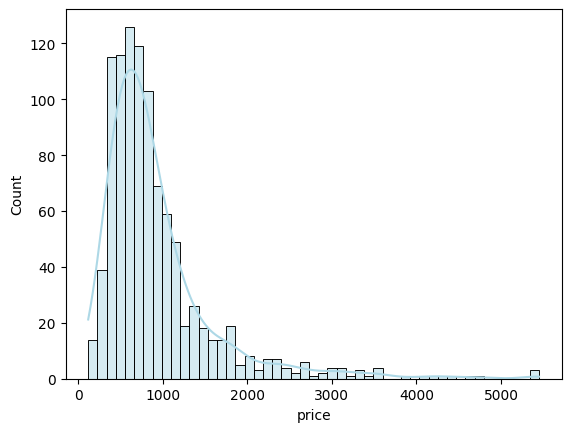

In [88]:
# Variáveis numéricas
sns.histplot(df_laptops['price'], kde=True, color='lightblue')

<Axes: xlabel='rating', ylabel='Count'>

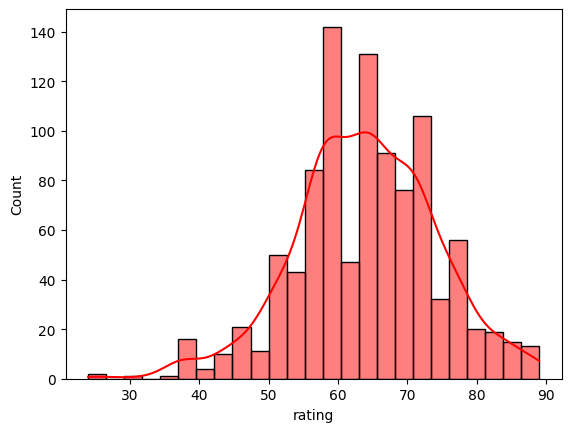

In [89]:
# Variáveis numéricas Variáveis Rating
sns.histplot(df_laptops['rating'], kde=True, color='red')

In [90]:
# Distriuição de Distribuição entre Brand e Price
px.box(df_laptops, x='price', y='brand', color='brand')

In [91]:
# Distriuição de Distribuição entre Brand e Rating
px.box(df_laptops, x='rating', y='brand', color='brand')

In [92]:
# Scatter plot entre Price e Rating
px.scatter(df_laptops, x='price', y='rating', color='brand')

### Treinar modelo de cluster hierarquico

In [93]:
# Seleconar as colunas para o clustering
X = df_laptops.copy()

# Remover colunas desnecessárias
X.drop(columns=['index', 'model'], axis=1, inplace=True)

In [94]:
X

,brand,price,rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,primary_storage_type,primary_storage_capacity,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,os,year_of_warranty
0,tecno,287.72,63,intel,core i3,2,4,8,SSD,512,intel,integrated,0,15.6,1920,1080,windows,1
1,tecno,431.64,67,intel,core i7,4,8,16,SSD,1024,intel,integrated,0,15.6,1920,1080,windows,1
2,hp,612.86,73,amd,ryzen 5,6,12,8,SSD,512,amd,dedicated,0,15.6,1920,1080,windows,1
3,acer,479.62,62,intel,core i5,12,16,8,SSD,512,intel,integrated,0,14.0,1920,1080,windows,1
4,lenovo,342.77,62,amd,ryzen 3,4,8,8,SSD,512,amd,integrated,0,15.6,1920,1080,windows,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,asus,791.44,68,amd,ryzen 5,6,12,16,SSD,512,nvidia,dedicated,0,15.6,1920,1080,windows,1
987,msi,1103.27,73,intel,core i7,10,16,16,SSD,512,nvidia,dedicated,0,15.6,1920,1080,windows,2
988,asus,539.58,59,amd,ryzen 5,4,8,8,SSD,512,amd,integrated,0,15.6,1920,1080,windows,1
989,asus,815.43,68,amd,ryzen 5,6,12,16,SSD,512,amd,integrated,0,14.0,2560,1600,windows,1


In [95]:
# Separar variáveis numéricas e categóricas
numeric_features = ['price', 'rating', 'num_cores', 'num_threads', 'ram_memory', 'primary_storage_capacity', 
                    'display_size', 'resolution_width', 'resolution_height']
categorical_features = ['brand', 'processor_brand', 'gpu_brand', 'gpu_type', 'os']

In [96]:
# Definir transformações
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

In [97]:
# Criar Pre Processor de Transformação
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [98]:
# Transformar os dados
X_transformed = preprocessor.fit_transform(X)

In [99]:
X_transformed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13874 stored elements and shape (991, 54)>

In [100]:
# Definir os hiperparÂmetros para o Optuna
def hierarchical_aglomeraive_objective(trial):
    n_clusters = trial.suggest_int('n_clusters', 10, 150)
    linkage = trial.suggest_categorical('linkage', ['ward',  'average', 'complete', 'single'])

    hierarchical_model = AgglomerativeClustering(linkage=linkage, n_clusters=n_clusters)

    # Treinar o modelo e executar a clusterização
    y = hierarchical_model.fit_predict(X_transformed.toarray())

    # Calcular o Silhouette Score
    silhouette_avg = silhouette_score(X_transformed, y)

    return silhouette_avg

In [101]:
# Criar estudo no Optuna
search_space_ag = {'n_clusters': range(10, 151), 'linkage': ['ward',  'average', 'complete', 'single']}
sampler_ag = optuna.samplers.GridSampler(search_space=search_space_ag)
estudo_ag = optuna.create_study(direction='maximize', sampler=sampler_ag)

[I 2026-03-10 10:24:02,726] A new study created in memory with name: no-name-b886330f-7616-45a8-94fc-abfe4879bc1d


In [102]:
# Executar estudo no Optuna para Agglomerative
estudo_ag.optimize(hierarchical_aglomeraive_objective, n_trials=600)


[I 2026-03-10 10:24:02,913] Trial 0 finished with value: 0.2234907963314824 and parameters: {'n_clusters': 108, 'linkage': 'average'}. Best is trial 0 with value: 0.2234907963314824.
[I 2026-03-10 10:24:03,501] Trial 1 finished with value: 0.17524794730527618 and parameters: {'n_clusters': 44, 'linkage': 'complete'}. Best is trial 0 with value: 0.2234907963314824.
[I 2026-03-10 10:24:04,033] Trial 2 finished with value: 0.18192511775951023 and parameters: {'n_clusters': 57, 'linkage': 'average'}. Best is trial 0 with value: 0.2234907963314824.
[I 2026-03-10 10:24:04,201] Trial 3 finished with value: 0.17426651499876017 and parameters: {'n_clusters': 46, 'linkage': 'complete'}. Best is trial 0 with value: 0.2234907963314824.
[I 2026-03-10 10:24:04,340] Trial 4 finished with value: 0.22831449937222206 and parameters: {'n_clusters': 140, 'linkage': 'complete'}. Best is trial 4 with value: 0.22831449937222206.
[I 2026-03-10 10:24:04,466] Trial 5 finished with value: 0.2354443546476447 and 

In [103]:
# Mostrar a melhor configuração do Optuna para Agglomerative
best_params_ag = estudo_ag.best_params

print(f'Clusters = {best_params_ag['n_clusters']}')
print(f'Linkage = {best_params_ag['linkage']}')

Clusters = 149
Linkage = ward


In [104]:
best_params_ag

{'n_clusters': 149, 'linkage': 'ward'}

In [105]:
# Definir os hiperparÂmetros para o Optuna
def hierarchical_aglomeraive_objective(trial):
    n_clusters = trial.suggest_int('n_clusters', 10, 150)

    hierarchical_model = BisectingKMeans(n_clusters=n_clusters)

    # Treinar o modelo e executar a clusterização
    y = hierarchical_model.fit_predict(X_transformed.toarray())

    # Calcular o Silhouette Score
    silhouette_avg = silhouette_score(X_transformed, y)

    return silhouette_avg

In [106]:
# Criar estudo no Optuna
search_space_di = {'n_clusters': range(10, 151)}
sampler_di = optuna.samplers.GridSampler(search_space=search_space_di)
estudo_di = optuna.create_study(direction='maximize', sampler=sampler_di)

[I 2026-03-10 10:36:52,170] A new study created in memory with name: no-name-660177b5-4835-4e8a-80ea-0b5017eb2709


In [108]:
# Executar estudo no Optuna para Agglomerative
estudo_di.optimize(hierarchical_aglomeraive_objective, n_trials=200)

[I 2026-03-10 10:38:06,149] Trial 0 finished with value: 0.14938474130022908 and parameters: {'n_clusters': 55}. Best is trial 0 with value: 0.14938474130022908.
[I 2026-03-10 10:38:06,503] Trial 1 finished with value: 0.15049621170144825 and parameters: {'n_clusters': 70}. Best is trial 1 with value: 0.15049621170144825.
[I 2026-03-10 10:38:06,623] Trial 2 finished with value: 0.14473611467477257 and parameters: {'n_clusters': 17}. Best is trial 1 with value: 0.15049621170144825.
[I 2026-03-10 10:38:06,974] Trial 3 finished with value: 0.15487259314614402 and parameters: {'n_clusters': 61}. Best is trial 3 with value: 0.15487259314614402.
[I 2026-03-10 10:38:07,251] Trial 4 finished with value: 0.1506963164705308 and parameters: {'n_clusters': 76}. Best is trial 3 with value: 0.15487259314614402.
[I 2026-03-10 10:38:07,446] Trial 5 finished with value: 0.13917754145727038 and parameters: {'n_clusters': 37}. Best is trial 3 with value: 0.15487259314614402.
[I 2026-03-10 10:38:07,742] T

In [109]:
# Mostrar a melhor configuração do Optuna para (divisive)
best_params_di = estudo_di.best_params

print(f'Clusters = {best_params_di['n_clusters']}')


Clusters = 146


In [111]:
# Criar modelo com a melhor configuração do Optuna para Agglomerative

best_model = AgglomerativeClustering(
    n_clusters=best_params_ag['n_clusters'],
    linkage=best_params_ag['linkage']
)

### Treinar modelo

In [112]:
# Treinar o modelo e executar a clusterização
best_model.fit(X_transformed.toarray())

AgglomerativeClustering(n_clusters=149)

In [113]:
# Verificar silhouete score
best_score = silhouette_score(X_transformed, best_model.labels_)
best_score

0.32745480721431686

In [114]:
# Criar uma coluna com cluster escolhido no DataFrame original
df_laptops['cluster'] = best_model.labels_

In [115]:
# Mostrar Chart com Trials do Optuna
fig = optuna.visualization.plot_optimization_history(estudo_ag)
fig.show()


In [116]:
# Treinar o modelo com scipy
modelo_de = linkage(X_transformed.toarray(), method=best_params_ag['linkage'], optimal_ordering=True)


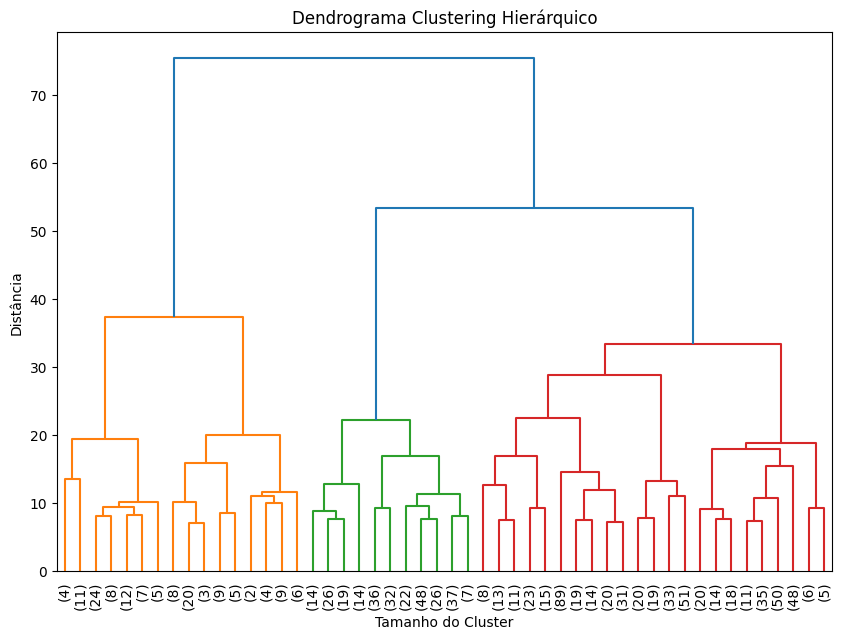

In [118]:
# Mostrar o dendrograma
plt.figure(figsize=(10, 7))
dendrogram(modelo_de, truncate_mode='lastp', p=50, leaf_rotation=90., leaf_font_size=10) 
plt.title('Dendrograma Clustering Hierárquico')
plt.xlabel('Tamanho do Cluster')
plt.ylabel('Distância')
plt.show()

In [119]:
# Cortar o Dendrograma
clusters_de_scipy = cut_tree(modelo_de, height=32)
len(np.unique(clusters_de_scipy))

5

In [120]:
# Cruzamento entre brand e price, apresentando os clusters 
px.scatter(df_laptops, x='brand', y='price', color='cluster')

In [131]:
# Cruzamento entre brand e price, apresentando os clusters 
px.scatter(df_laptops, x='cluster', y='price', color='cluster')

In [122]:
# Cruzamento entre brand e price, apresentando os clusters A
px.scatter(df_laptops, x='brand', y='price', color='cluster')

In [123]:
# Cruzamento entre brand e price, apresentando os clusters A
px.scatter(df_laptops, x='brand', y='rating', color='cluster')

In [124]:
# Cruzamento entre brand e price, apresentando os clusters A
px.scatter(df_laptops, x='cluster', y='rating', color='brand')

In [125]:
# Distribuição da variável clusters
percentual_cluster = df_laptops.value_counts('cluster') / len(df_laptops) * 100
px.bar(percentual_cluster, color=percentual_cluster.index)

In [126]:
# Distribuição da variável cluster
quantidade_cluster = df_laptops.value_counts('cluster')
px.bar(quantidade_cluster, color=quantidade_cluster.index)

# Salvar o modelo, PreProcessor e CSV Atualizado

In [128]:
# Saslvar o modelo 
joblib.dump(best_model, './modelo_hierarquico_laptos.pkl')

# Salvar o preprocessor
joblib.dump(preprocessor, './preprocessor_hierarquico_laptos.pkl')

['./preprocessor_hierarquico_laptos.pkl']

In [129]:
# Salvar CSV atulaizado com dados de cluster 
df_laptops.to_csv('./dataset/dados_notebook_clusterizado.csv', index=False)